In [1]:
!pip install -q omegaconf==2.3.0 einx==0.3.0


[notice] A new release of pip is available: 23.1.2 -> 25.0.1
[notice] To update, run: python3.9 -m pip install --upgrade pip


In [2]:
!git clone https://github.com/SparkAudio/Spark-TTS.git

Cloning into 'Spark-TTS'...
remote: Enumerating objects: 361, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 361 (delta 37), reused 29 (delta 29), pack-reused 314 (from 2)
Receiving objects: 100% (361/361), 7.07 MiB | 8.88 MiB/s, done.
Resolving deltas: 100% (140/140), done.


In [1]:
import dataclasses
from glob import glob
from typing import Tuple, Any, List, Dict
import math
import os
import copy
import re
import IPython.display

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt
from fastprogress import progress_bar as pb
import datasets
from datasets import load_dataset
import transformers
from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM, BitsAndBytesConfig
# from sentence_transformers import SentenceTransformer
import einops
from PIL import Image
import bitsandbytes as bnb

import warnings
warnings.simplefilter('ignore')

import sys
sys.path.append('Spark-TTS')
from sparktts.models.audio_tokenizer import BiCodecTokenizer
from sparktts.utils.token_parser import LEVELS_MAP, GENDER_MAP, TASK_TOKEN_MAP

os.environ['TOKENIZERS_PARALLELISM'] = 'false'

## 1. Configs

In [2]:
N_EPOCHS = 20
TRAIN_BATCH_SIZE = TEST_BATCH_SIZE = 2#16#8#32
LR = 1e-3
WEIGHT_DECAY = 1e-2
USE_AMP = True
# AMP_DTYPE = torch.float16
# dtype = torch.float16
# llm_dtype = torch.float16
# AMP_DTYPE = torch.bfloat16
# dtype = torch.bfloat16
# llm_dtype = torch.bfloat16
AMP_DTYPE = torch.bfloat16
dtype = torch.float32
llm_dtype = torch.float32

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

## 2. Load Model/Tolkenizer

In [ ]:
if not os.path.exists('pretrained_models/Spark-TTS-0.5B'):
    !rm -rf pretrained_models
    from huggingface_hub import snapshot_download
    snapshot_download("SparkAudio/Spark-TTS-0.5B", local_dir="pretrained_models/Spark-TTS-0.5B")

In [4]:
model_dir = 'pretrained_models/Spark-TTS-0.5B'

In [5]:
tokenizer = AutoTokenizer.from_pretrained(f"{model_dir}/LLM")
model = AutoModelForCausalLM.from_pretrained(f"{model_dir}/LLM")
audio_tokenizer = BiCodecTokenizer(model_dir, device=device)
model.to(device)

Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


Missing tensor: mel_transformer.spectrogram.window
Missing tensor: mel_transformer.mel_scale.fb


Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(166000, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((896,), eps=1e-06)
    (rotary_emb): Qwen2RotaryEmbe

In [6]:
model.dtype

torch.float32

## 3. Prepare Dataset

In [15]:
if not os.path.exists('tsukuyomi'):
    !wget https://tyc.rei-yumesaki.net/files/voice/tyc-corpus1.zip
    !rm -rf tsukuyomi/
    !unzip -q -O sjis tyc-corpus1.zip -d tsukuyomi/
    !rm tyc-corpus1.zip

--2025-03-15 10:55:05--  https://tyc.rei-yumesaki.net/files/voice/tyc-corpus1.zip
Resolving tyc.rei-yumesaki.net (tyc.rei-yumesaki.net)... 162.43.94.40
Connecting to tyc.rei-yumesaki.net (tyc.rei-yumesaki.net)|162.43.94.40|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 516635952 (493M) [application/zip]
Saving to: ‘tyc-corpus1.zip’

tyc-corpus1.zip     100%[===================>] 492.70M  7.08MB/s    in 74s     

2025-03-15 10:56:19 (6.68 MB/s) - ‘tyc-corpus1.zip’ saved [516635952/516635952]



In [7]:
WAV_ORG_DIR = 'tsukuyomi/つくよみちゃんコーパス Vol.1 声優統計コーパス（JVSコーパス準拠）/02 WAV（+12dB増幅）'
TRANSCRIPT_FILEPATH = 'tsukuyomi/つくよみちゃんコーパス Vol.1 声優統計コーパス（JVSコーパス準拠）/04 台本と補足資料/★台本テキスト/01 補足なし台本（JSUTコーパス・JVSコーパス版）.txt'

In [8]:
tkym_wavs = glob(f'{WAV_ORG_DIR}/*.wav')
len(tkym_wavs)

100

In [9]:
def parse_trainscript(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    filename_list = []
    text_list = []
    for line in lines:
        filename_list.append(line.split(':')[0])
        text_list.append(line.split(':')[1].replace('\n', ''))
    return filename_list, text_list

wav_filename_list, text_list = parse_trainscript(TRANSCRIPT_FILEPATH)

In [17]:
df_wav = pd.DataFrame({'wav_filepath': tkym_wavs})
df_wav['wav_filename'] = df_wav['wav_filepath'].apply(lambda x: x.split('/')[-1].replace('.wav', ''))
df_text = pd.DataFrame({'wav_filename': wav_filename_list, 'text': text_list})
df_wav_text = pd.merge(df_wav, df_text, on='wav_filename')

In [18]:
df_wav_text

,wav_filepath,wav_filename,text
0,tsukuyomi/つくよみちゃんコーパス Vol.1 声優統計コーパス（JVSコーパス準拠...,VOICEACTRESS100_044,クウェーンバーンチャーンは、小さなコミュニティーで、農業や、商業を中心に、成り立っていたと、...
1,tsukuyomi/つくよみちゃんコーパス Vol.1 声優統計コーパス（JVSコーパス準拠...,VOICEACTRESS100_065,レギュラーメンバーの顔写真をクリックした後に、ムービープレイヤー風に再生されるという、特異な...
2,tsukuyomi/つくよみちゃんコーパス Vol.1 声優統計コーパス（JVSコーパス準拠...,VOICEACTRESS100_022,このときに、浮遊大陸プルヴァマにある、中立国、ビュエルバが、ある情報筋から、バッシュ将軍の処...
3,tsukuyomi/つくよみちゃんコーパス Vol.1 声優統計コーパス（JVSコーパス準拠...,VOICEACTRESS100_029,現在の滑走を目的とした、スキーブーツは、硬いプラスチックシェルと、柔らかいインナーブーツからなる。
4,tsukuyomi/つくよみちゃんコーパス Vol.1 声優統計コーパス（JVSコーパス準拠...,VOICEACTRESS100_036,番組冒頭を、東京ムービー製作のアニメーションで、表現する点も、共通していた。
...,...,...,...
95,tsukuyomi/つくよみちゃんコーパス Vol.1 声優統計コーパス（JVSコーパス準拠...,VOICEACTRESS100_082,カーミラ星と呼ばれている惑星から、宇宙船に乗って、地球に侵入した宇宙人。
96,tsukuyomi/つくよみちゃんコーパス Vol.1 声優統計コーパス（JVSコーパス準拠...,VOICEACTRESS100_019,ベルガートーア前の、ヴェディゲンウーファーパークには、戦争と弾圧の犠牲者のための記念碑が建っ...
97,tsukuyomi/つくよみちゃんコーパス Vol.1 声優統計コーパス（JVSコーパス準拠...,VOICEACTRESS100_003,コンピュータゲームのメーカーや、業界団体などに関連する人物のカテゴリ。
98,tsukuyomi/つくよみちゃんコーパス Vol.1 声優統計コーパス（JVSコーパス準拠...,VOICEACTRESS100_087,福岡ダイエーホークスではなく、長距離砲の補強を目指していた、大阪近鉄バファローズから、オファ...


In [12]:
assert ~df_wav_text.isnull().any().any()

In [13]:
hf_dataset = datasets.Dataset.from_pandas(df_wav_text)

In [14]:
hf_dataset

Dataset({
    features: ['wav_filepath', 'wav_filename', 'text'],
    num_rows: 100
})

In [30]:
def preprocess_data(examples, audio_tokenizer=audio_tokenizer, tokenizer=tokenizer):
    tokenizer_inputs_for_gen_list = []
    tokenizer_inputs_for_train_list = []
    for tgt_speech_path, tgt_text in zip(examples['wav_filepath'], examples['text']):
        sr_random_prompt_wav = df_wav_text.sample(1).iloc[0]
        prompt_speech_path = sr_random_prompt_wav.wav_filepath
        prompt_text = sr_random_prompt_wav.text
        global_token_ids_prompt, semantic_token_ids_prompt = audio_tokenizer.tokenize(
            prompt_speech_path
        )
        global_token_ids_tgt, semantic_token_ids_tgt = audio_tokenizer.tokenize(
            tgt_speech_path
        )
        global_tokens_prompt = "".join(
            [f"<|bicodec_global_{i}|>" for i in global_token_ids_prompt.squeeze()]
        )
        # Prepare the input tokens for the model
        # TODO: research how to prepare prompt for training
        semantic_tokens_prompt = "".join(
            [f"<|bicodec_semantic_{i}|>" for i in semantic_token_ids_prompt.squeeze()]
        )
        semantic_tokens_tgt = "".join(
            [f"<|bicodec_semantic_{i}|>" for i in semantic_token_ids_tgt.squeeze()]
        )
        inputs_for_gen = [
            TASK_TOKEN_MAP["tts"],
            "<|start_content|>",
            prompt_text,
            tgt_text,
            "<|end_content|>",
            "<|start_global_token|>",
            global_tokens_prompt,
            "<|end_global_token|>",
            "<|start_semantic_token|>",
            semantic_tokens_prompt,
        ]
        inputs_for_train = inputs_for_gen + [semantic_tokens_tgt]

        prompt_for_gen = "".join(inputs_for_gen)
        prompt_for_train = "".join(inputs_for_train)
        tokenizer_inputs_for_gen_list.append(prompt_for_gen)
        tokenizer_inputs_for_train_list.append(prompt_for_train)

    examples["tokenizer_inputs_gen"] = tokenizer_inputs_for_gen_list
    examples["tokenizer_inputs_train"] = tokenizer_inputs_for_train_list

    return examples

def collate_fn(examples):
    tokenized_inputs_gen = tokenizer([example["tokenizer_inputs_gen"] for example in examples], padding=True, return_tensors="pt").to(device)
    tokenized_inputs_train = tokenizer([example["tokenizer_inputs_train"] for example in examples], padding=True, return_tensors="pt").to(device)

    input_ids_gen_len = tokenized_inputs_gen['attention_mask'].sum(dim=-1)
    loss_target_pos_mask = torch.zeros_like(tokenized_inputs_train['input_ids']).to(device)
    for i in range(len(loss_target_pos_mask)):
        loss_target_pos_mask[i, input_ids_gen_len[i]:] = 1

    return {
        "loss_target_pos_mask": loss_target_pos_mask,
        **tokenized_inputs_train,
    }

In [23]:
%%time
hf_dataset = hf_dataset.with_transform(preprocess_data)

CPU times: user 1.67 s, sys: 753 ms, total: 2.42 s
Wall time: 2.42 s


In [24]:
_d = hf_dataset[0]

In [25]:
_d.keys()

dict_keys(['wav_filepath', 'wav_filename', 'text', 'tokenizer_inputs_gen', 'tokenizer_inputs_train'])

In [27]:
_d['tokenizer_inputs_train']

'<|task_tts|><|start_content|>時間領域と、空間領域で共通する処理手法は、フィルタリングによる、入力信号の強化である。クウェーンバーンチャーンは、小さなコミュニティーで、農業や、商業を中心に、成り立っていたと、考えられている。<|end_content|><|start_global_token|><|bicodec_global_2375|><|bicodec_global_199|><|bicodec_global_1640|><|bicodec_global_3785|><|bicodec_global_1514|><|bicodec_global_3856|><|bicodec_global_1159|><|bicodec_global_680|><|bicodec_global_3084|><|bicodec_global_1241|><|bicodec_global_878|><|bicodec_global_3160|><|bicodec_global_966|><|bicodec_global_3612|><|bicodec_global_3249|><|bicodec_global_1348|><|bicodec_global_60|><|bicodec_global_420|><|bicodec_global_3710|><|bicodec_global_1207|><|bicodec_global_452|><|bicodec_global_1234|><|bicodec_global_3628|><|bicodec_global_3214|><|bicodec_global_950|><|bicodec_global_2253|><|bicodec_global_3550|><|bicodec_global_2439|><|bicodec_global_707|><|bicodec_global_2436|><|bicodec_global_2828|><|bicodec_global_3732|><|end_global_token|><|start_semantic_token|><|bicodec_semantic_284|><|bicodec_semantic_1388|><|bicodec_semanti

In [31]:
train_dataloader = torch.utils.data.DataLoader(
    hf_dataset,
    shuffle=True,
    collate_fn=collate_fn,
    batch_size=TRAIN_BATCH_SIZE,
)
test_dataloader = torch.utils.data.DataLoader(
    hf_dataset,
    shuffle=False,
    collate_fn=collate_fn,
    batch_size=TEST_BATCH_SIZE,
)

In [32]:
_batch = next(iter(train_dataloader))

In [33]:
tokenizer.batch_decode(_batch['input_ids'])

['<|task_tts|><|start_content|>ペンシルベニア州、ピッツバーグの、アレゲーニー高校を卒業し、カリフォルニア大学、バークレー校に入学。ところが、エリュシクトーンは、ニュムペーの制止も聞かずに、デーメーテールの樫を、切り倒した。<|end_content|><|start_global_token|><|bicodec_global_2331|><|bicodec_global_199|><|bicodec_global_1464|><|bicodec_global_3790|><|bicodec_global_233|><|bicodec_global_2580|><|bicodec_global_3403|><|bicodec_global_684|><|bicodec_global_3340|><|bicodec_global_154|><|bicodec_global_634|><|bicodec_global_3240|><|bicodec_global_726|><|bicodec_global_3628|><|bicodec_global_3190|><|bicodec_global_2141|><|bicodec_global_56|><|bicodec_global_2789|><|bicodec_global_3706|><|bicodec_global_3259|><|bicodec_global_329|><|bicodec_global_226|><|bicodec_global_2092|><|bicodec_global_2190|><|bicodec_global_1913|><|bicodec_global_2508|><|bicodec_global_3551|><|bicodec_global_3215|><|bicodec_global_1731|><|bicodec_global_1092|><|bicodec_global_3912|><|bicodec_global_3476|><|end_global_token|><|start_semantic_token|><|bicodec_semantic_5668|><|bicodec_semantic_5547|><|bicodec_semant

In [34]:
tokenizer.batch_decode(_batch['input_ids'] * _batch['loss_target_pos_mask'])

['!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!<|bicodec_semantic_4267|><|bicodec_semantic_155|><|bicodec_semantic_110|><|bicodec_semantic_3076|><|bicodec_semantic_1119|><|bicodec_semantic_7909|><|bicodec_semantic_7667|><|bicodec_semantic_211|><|bicodec_semantic_1142|><|bicodec_semantic_2823|><|bicodec_semantic_3914|><|bicodec_semantic_6284|><|bicodec_semantic_7160|><|bicodec_semantic_7953|><|bicodec_semantic_6171|><|bicodec_semantic_4704|><|bicodec_semantic_4115|><|bicodec_semantic_2300|><|bicodec_se

## 4. Model

In [35]:
# bnb_config = BitsAndBytesConfig(
#     load_in_8bit=True,
#     bnb_8bit_compute_dtype=llm_dtype,
# )
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    # bnb_4bit_use_double_quant=False,
    bnb_4bit_compute_dtype=llm_dtype,
)

In [36]:
from peft import LoraConfig, TaskType, get_peft_model, prepare_model_for_kbit_training

# LoRAの設定
peft_config = LoraConfig(
    r=32,
    lora_alpha=32,
    lora_dropout=0.05,
    task_type=TaskType.CAUSAL_LM,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        # "gate_proj",
        # "up_proj",
        # "down_proj",
    ],
)

# model.enable_input_require_grads()
model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

trainable params: 4,325,376 || all params: 510,959,488 || trainable%: 0.8465


In [37]:
model.dtype, llm_dtype

(torch.float32, torch.float32)

In [38]:
# _ = llm_model.vision_model.requires_grad_(False)

In [39]:
for name, p in model.named_parameters():
    if p.requires_grad:
        print(name, p.requires_grad)

base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight True
base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight True
base_model.model.model.layers.0.self_attn.k_proj.lora_A.default.weight True
base_model.model.model.layers.0.self_attn.k_proj.lora_B.default.weight True
base_model.model.model.layers.0.self_attn.v_proj.lora_A.default.weight True
base_model.model.model.layers.0.self_attn.v_proj.lora_B.default.weight True
base_model.model.model.layers.0.self_attn.o_proj.lora_A.default.weight True
base_model.model.model.layers.0.self_attn.o_proj.lora_B.default.weight True
base_model.model.model.layers.1.self_attn.q_proj.lora_A.default.weight True
base_model.model.model.layers.1.self_attn.q_proj.lora_B.default.weight True
base_model.model.model.layers.1.self_attn.k_proj.lora_A.default.weight True
base_model.model.model.layers.1.self_attn.k_proj.lora_B.default.weight True
base_model.model.model.layers.1.self_attn.v_proj.lora_A.default.weight True
base_model.m

In [40]:
train_models = [model]

## 5. Training

In [41]:
@torch.inference_mode()
def generate(
    model,
    text: str,
    prompt_speech_path=None,
    prompt_text=None,
    max_new_tokens=3000,
    top_k=50,
    top_p=0.95,
    temperature=0.8
):
    global_token_ids, semantic_token_ids = audio_tokenizer.tokenize(
        prompt_speech_path
    )
    global_tokens = "".join(
        [f"<|bicodec_global_{i}|>" for i in global_token_ids.squeeze()]
    )
    # Prepare the input tokens for the model
    if prompt_text is not None:
        semantic_tokens = "".join(
            [f"<|bicodec_semantic_{i}|>" for i in semantic_token_ids.squeeze()]
        )
        inputs = [
            TASK_TOKEN_MAP["tts"],
            "<|start_content|>",
            prompt_text,
            text,
            "<|end_content|>",
            "<|start_global_token|>",
            global_tokens,
            "<|end_global_token|>",
            "<|start_semantic_token|>",
            semantic_tokens,
        ]
    else:
        inputs = [
            TASK_TOKEN_MAP["tts"],
            "<|start_content|>",
            text,
            "<|end_content|>",
            "<|start_global_token|>",
            global_tokens,
            "<|end_global_token|>",
        ]
    prompt = "".join(inputs)
    model_inputs = tokenizer([prompt], return_tensors="pt").to(device)

    # Generate speech using the model
    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        top_k=top_k,
        top_p=top_p,
        temperature=temperature,
    )
    # Trim the output tokens to remove the input tokens
    generated_ids = [
        output_ids[len(input_ids) :]
        for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]
    # Decode the generated tokens into text
    predicts = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
    # Extract semantic token IDs from the generated text
    pred_semantic_ids = (
        torch.tensor([int(token) for token in re.findall(r"bicodec_semantic_(\d+)", predicts)])
        .long()
        .unsqueeze(0)
    )
    # if gender is not None:
    #     global_token_ids = (
    #         torch.tensor([int(token) for token in re.findall(r"bicodec_global_(\d+)", predicts)])
    #         .long()
    #         .unsqueeze(0)
    #         .unsqueeze(0)
    #     )
    # Convert semantic tokens back to waveform
    wav = audio_tokenizer.detokenize(
        global_token_ids.to(device).squeeze(0),
        pred_semantic_ids.to(device),
    )
    return wav

In [42]:
def batch_to_device(batch: Dict[str, torch.Tensor], device: torch.device) -> Dict[str, torch.Tensor]:
    return {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}

In [43]:
def get_trainable_params(models):
    params = []
    for model in models:
        params += [p for p in model.parameters() if p.requires_grad]
    return params

In [44]:
# optimizer = torch.optim.AdamW(
optimizer = bnb.optim.AdamW8bit(
    # nn.ModuleList(train_models).parameters(),
    get_trainable_params(train_models),
    lr=LR, weight_decay=WEIGHT_DECAY
)

scheduler = transformers.get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=1*len(train_dataloader),
    num_training_steps=N_EPOCHS*len(train_dataloader),
)

scaler = torch.amp.GradScaler(device=device, enabled=USE_AMP)

In [59]:
IPython.display.Audio(
    generate(
        model=model,
        text='太平洋側を中心に雨や風が強まりそう。九州など局地的に大雨となるおそれ。',
        prompt_speech_path=df_wav_text['wav_filepath'].iloc[0],
        prompt_text=df_wav_text['text'].iloc[0],
    ),
    rate=16000,
)

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


In [45]:
loss_history = []
train_acc_history = []
test_acc_history = []

In [ ]:
for epoch in range(N_EPOCHS):
    if epoch > 0:
        # Train phase
        [m.train() for m in train_models]
        epoch_loss = 0.0
        pred_labels = []
        true_labels = []
        metric_target_mask_list = []
        for batch in pb(train_dataloader):
            batch = batch_to_device(batch, device)
            loss_target_pos_mask = batch.pop('loss_target_pos_mask')
            target_labels = batch['input_ids'][:, 1:].clone()  # (bs, seq_len -1)
            target_labels[loss_target_pos_mask[:, :-1] == 0] = -100
            optimizer.zero_grad()
            with torch.autocast(device_type=device, dtype=AMP_DTYPE, enabled=USE_AMP):
                llm_out = model(
                    input_ids=batch['input_ids'],
                    attention_mask=batch['attention_mask'],
                )
                pred_logits = llm_out.logits.to(dtype)[:, :-1, :]  # (bs, seq_len - 1, vocab_size)
                assert pred_logits.shape[:2] == target_labels.shape
                loss = torch.nn.functional.cross_entropy(pred_logits.transpose(1, 2).float(), target_labels, ignore_index=-100)
                if torch.isnan(loss):
                    print('loss is nan')
                    raise Exception()
                pred_labels.append(pred_logits.argmax(-1).long().cpu().detach())
                true_labels.append(target_labels.cpu().detach())
                metric_target_mask_list.append((loss_target_pos_mask * batch['attention_mask'])[:, :-1].cpu())
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            # loss.backward()
            # optimizer.step()
            scaler.update()
            scheduler.step()
            epoch_loss += loss.cpu().detach()
        pred_labels_flat = torch.cat([l.flatten() for l in pred_labels], dim=0)
        true_labels_flat = torch.cat([l.flatten() for l in true_labels], dim=0)
        metric_target_mask_flat = torch.cat([m.flatten() for m in metric_target_mask_list], dim=0)
        acc = ((pred_labels_flat == true_labels_flat).long() * metric_target_mask_flat.cpu()).sum() / metric_target_mask_flat.sum()
        train_acc_history.append(acc)
        loss_history.append(epoch_loss / len(train_dataloader))
        print(f'epoch {epoch} : loss {loss_history[-1]} : acc {acc}')

    # Ealuluation Phase
    [m.eval() for m in train_models]
    gen_wav = generate(
        model=model,
        text='太平洋側を中心に雨や風が強まりそう。九州など局地的に大雨となるおそれ。',
        prompt_speech_path=df_wav_text['wav_filepath'].iloc[0],
        prompt_text=df_wav_text['text'].iloc[0],
    )
    display(IPython.display.Audio(gen_wav, rate=16000))
    # pred_labels = []
    # true_labels = []
    # metric_target_mask_list = []
    # with torch.inference_mode():
    #     for batch in pb(test_dataloader):
    #         batch = batch_to_device(batch, device)
    #         # pixel_values = batch.pop('pixel_values')
    #         loss_target_pos_mask = batch.pop('loss_target_pos_mask')
    #         target_labels = batch['input_ids'][:, 1:].clone()  # (bs, seq_len -1)
    #         target_labels[loss_target_pos_mask[:, :-1] == 0] = -100
    #         optimizer.zero_grad()
    #         with torch.autocast(device_type=device, dtype=AMP_DTYPE, enabled=USE_AMP):
    #             llm_out = model(
    #                 input_ids=batch['input_ids'],
    #                 attention_mask=batch['attention_mask'],
    #             )
    #             pred_logits = llm_out.logits.to(dtype)[:, :-1, :]  # (bs, seq_len - 1, vocab_size)
    #             assert pred_logits.shape[:2] == target_labels.shape
    #             loss = torch.nn.functional.cross_entropy(pred_logits.transpose(1, 2).float(), target_labels, ignore_index=-100)
    #             if torch.isnan(loss):
    #                 print('loss is nan')
    #                 raise Exception()
    #             pred_labels.append(pred_logits.argmax(-1).long().cpu().detach())
    #             true_labels.append(target_labels.cpu().detach())
    #             metric_target_mask_list.append((loss_target_pos_mask * batch['attention_mask'])[:, :-1].cpu())
    # pred_labels_flat = torch.cat([l.flatten() for l in pred_labels], dim=0)
    # true_labels_flat = torch.cat([l.flatten() for l in true_labels], dim=0)
    # metric_target_mask_flat = torch.cat([m.flatten() for m in metric_target_mask_list], dim=0)
    # acc = ((pred_labels_flat == true_labels_flat).long() * metric_target_mask_flat.cpu()).sum() / metric_target_mask_flat.sum()
    # test_acc_history.append(acc)
    # print(f'epoch {epoch} : test acc {test_acc_history[-1]}')

    print(scheduler.get_lr())

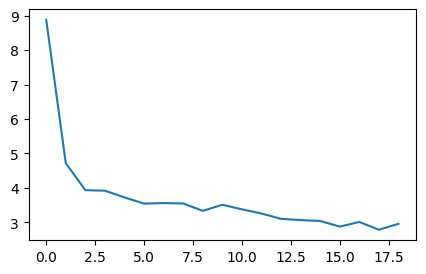

In [47]:
plt.figure(figsize=(5, 3))
plt.plot(loss_history)

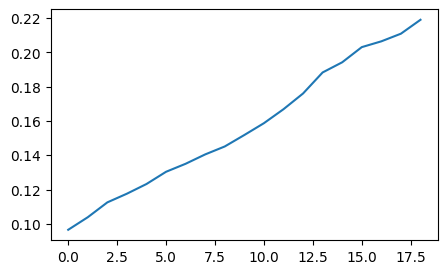

In [48]:
plt.figure(figsize=(5, 3))
plt.plot(train_acc_history)

GPU memory～12GB

## 6. Generation with Trained Model

In [49]:
_ = [m.eval() for m in train_models]

In [50]:
gen_wav = generate(
    model=model,
    text='太平洋側を中心に雨や風が強まりそう。九州など局地的に大雨となるおそれ。',
    prompt_speech_path=df_wav_text['wav_filepath'].iloc[0],
    prompt_text=df_wav_text['text'].iloc[0],
)
display(IPython.display.Audio(gen_wav, rate=16000))

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


In [51]:
model.save_pretrained('trained_weights')